# ITSM MACHINE LEARNING PROJECT
# High Priority Prediction

In [1]:
# 1. Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector
import pymysql

from sqlalchemy import create_engine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier
from prophet import Prophet



c:\Users\ADMIN\Downloads\Project data sets\python\.venv\projects\mini projects\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [2]:
host = "18.136.157.135"
user = "dm_team"
password = "DM!$Team@&27920!"
database = "project_itsm"

In [3]:
# # Connect using mysql.connector
conn = mysql.connector.connect(
    host=host,
    user=user,
    password=password,
    database=database
)
cursor = conn.cursor()
cursor.execute("SHOW TABLES;")          


In [4]:
cursor 

In [5]:
for table in cursor.fetchall():
     print(table)


('dataset_list',)


In [6]:
# # Read from the only table: dataset_list
query = "SELECT * FROM dataset_list;"
df = pd.read_sql(query, conn)

conn.close()


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_2372\2750948911.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [7]:
df

,CI_Name,CI_Cat,CI_Subcat,WBS,Incident_ID,Status,Impact,Urgency,Priority,number_cnt,...,Reopen_Time,Resolved_Time,Close_Time,Handle_Time_hrs,Closure_Code,No_of_Related_Interactions,Related_Interaction,No_of_Related_Incidents,No_of_Related_Changes,Related_Change
0,SUB000508,subapplication,Web Based Application,WBS000162,IM0000004,Closed,4,4,4,0.601292279,...,,04-11-2013 13:50,04-11-2013 13:51,"3,87,16,91,111",Other,1,SD0000007,2,,
1,WBA000124,application,Web Based Application,WBS000088,IM0000005,Closed,3,3,3,0.415049969,...,02-12-2013 12:31,02-12-2013 12:36,02-12-2013 12:36,"4,35,47,86,389",Software,1,SD0000011,1,,
2,DTA000024,application,Desktop Application,WBS000092,IM0000006,Closed,NS,3,NA,0.517551335,...,,13-01-2014 15:12,13-01-2014 15:13,"4,84,31,19,444",No error - works as designed,1,SD0000017,,,
3,WBA000124,application,Web Based Application,WBS000088,IM0000011,Closed,4,4,4,0.642927218,...,,14-11-2013 09:31,14-11-2013 09:31,"4,32,18,33,333",Operator error,1,SD0000025,,,
4,WBA000124,application,Web Based Application,WBS000088,IM0000012,Closed,4,4,4,0.345258343,...,,08-11-2013 13:55,08-11-2013 13:55,"3,38,39,03,333",Other,1,SD0000029,,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46601,SBA000464,application,Server Based Application,WBS000073,IM0047053,Closed,4,4,4,0.23189604,...,,31-03-2014 16:29,31-03-2014 16:29,"0,095",Other,1,SD0147021,,,
46602,SBA000461,application,Server Based Application,WBS000073,IM0047054,Closed,4,4,4,0.805153085,...,,31-03-2014 15:29,31-03-2014 15:29,"0,428333333",User error,1,SD0146967,,,
46603,LAP000019,computer,Laptop,WBS000091,IM0047055,Closed,5,5,5,0.917466294,...,,31-03-2014 15:32,31-03-2014 15:32,"0,071666667",Hardware,1,SD0146982,,,
46604,WBA000058,application,Web Based Application,WBS000073,IM0047056,Closed,4,4,4,0.701278158,...,,31-03-2014 15:42,31-03-2014 15:42,"0,116944444",Software,1,SD0146986,,,


In [8]:
df.shape

(46606, 25)

In [9]:
df.isnull().sum()

CI_Name                       0
CI_Cat                        0
CI_Subcat                     0
WBS                           0
Incident_ID                   0
Status                        0
Impact                        0
Urgency                       0
Priority                      0
number_cnt                    0
Category                      0
KB_number                     0
Alert_Status                  0
No_of_Reassignments           0
Open_Time                     0
Reopen_Time                   0
Resolved_Time                 0
Close_Time                    0
Handle_Time_hrs               0
Closure_Code                  0
No_of_Related_Interactions    0
Related_Interaction           0
No_of_Related_Incidents       0
No_of_Related_Changes         0
Related_Change                0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46606 entries, 0 to 46605
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   CI_Name                     46606 non-null  object
 1   CI_Cat                      46606 non-null  object
 2   CI_Subcat                   46606 non-null  object
 3   WBS                         46606 non-null  object
 4   Incident_ID                 46606 non-null  object
 5   Status                      46606 non-null  object
 6   Impact                      46606 non-null  object
 7   Urgency                     46606 non-null  object
 8   Priority                    46606 non-null  object
 9   number_cnt                  46606 non-null  object
 10  Category                    46606 non-null  object
 11  KB_number                   46606 non-null  object
 12  Alert_Status                46606 non-null  object
 13  No_of_Reassignments         46606 non-null  ob

In [12]:
# Convert datetime columns
date_cols = ['Open_Time', 'Resolved_Time', 'Close_Time']

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Create new features
df['Open_Year'] = df['Open_Time'].dt.year
df['Open_Month'] = df['Open_Time'].dt.month
df['Open_Day'] = df['Open_Time'].dt.day

# Handle missing values
df.fillna("Unknown", inplace=True)

# Convert Handle_Time_hrs properly
df['Handle_Time_hrs'] = pd.to_numeric(df['Handle_Time_hrs'], errors='coerce')


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_2372\771410920.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Unknown' has dtype incompatible with datetime64[ns], please explicitly cast to a compatible dtype first.
  df.fillna("Unknown", inplace=True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_2372\771410920.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Unknown' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.fillna("Unknown", inplace=True)


In [13]:
df['High_Priority'] = df['Priority'].apply(lambda x: 1 if x in [1,2] else 0)


In [14]:
categorical_cols = ['CI_Cat','CI_Subcat','Status','Alert_Status','Category']

le = LabelEncoder()

for col in categorical_cols:
    df[col] = df[col].astype(str)
    df[col] = le.fit_transform(df[col])


In [15]:
# Replace problematic values
df.replace("NS", np.nan, inplace=True)

# Convert numeric columns safely
numeric_cols = ['Impact', 'Urgency', 'No_of_Reassignments',
                'Handle_Time_hrs', 'No_of_Related_Changes']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Fill missing numeric values
df[numeric_cols] = df[numeric_cols].fillna(0)


In [16]:
df.fillna("Unknown", inplace=True)


In [17]:
numeric_cols = [
    'Impact',
    'Urgency',
    'Priority',
    'No_of_Reassignments',
    'Handle_Time_hrs',
    'No_of_Related_Changes'
]

categorical_cols = [
    'CI_Cat',
    'CI_Subcat',
    'Status',
    'Alert_Status',
    'Category'
]


In [18]:
# Replace problematic values
df.replace("Unknown", np.nan, inplace=True)
df.replace("NS", np.nan, inplace=True)

# Fix comma issue
df['Handle_Time_hrs'] = df['Handle_Time_hrs'].astype(str)
df['Handle_Time_hrs'] = df['Handle_Time_hrs'].str.replace(',', '.')

# Convert numeric safely
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Fill numeric missing values
df[numeric_cols] = df[numeric_cols].fillna(0)


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_2372\2067318199.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace("Unknown", np.nan, inplace=True)


In [19]:
features = ['CI_Cat','CI_Subcat','Impact','Urgency','No_of_Reassignments',
            'Open_Year','Open_Month']

X = df[features]
y = df['High_Priority']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)


In [20]:
model = RandomForestClassifier(n_estimators=200)
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9322

    accuracy                           1.00      9322
   macro avg       1.00      1.00      1.00      9322
weighted avg       1.00      1.00      1.00      9322



C:\Users\ADMIN\AppData\Local\Temp\ipykernel_2372\662529265.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = incident_count.resample('M').sum()


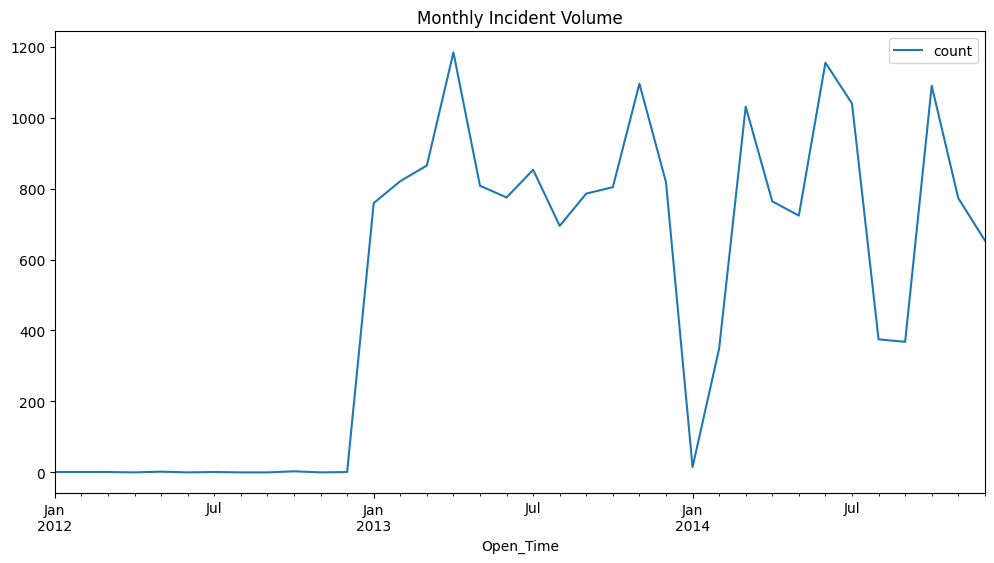

In [21]:
incident_count = df.groupby('Open_Time').size().reset_index(name='count')
incident_count.set_index('Open_Time', inplace=True)

monthly = incident_count.resample('M').sum()

monthly.plot(figsize=(12,6))
plt.title("Monthly Incident Volume")
plt.show()


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_2372\662529265.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = incident_count.resample('M').sum()


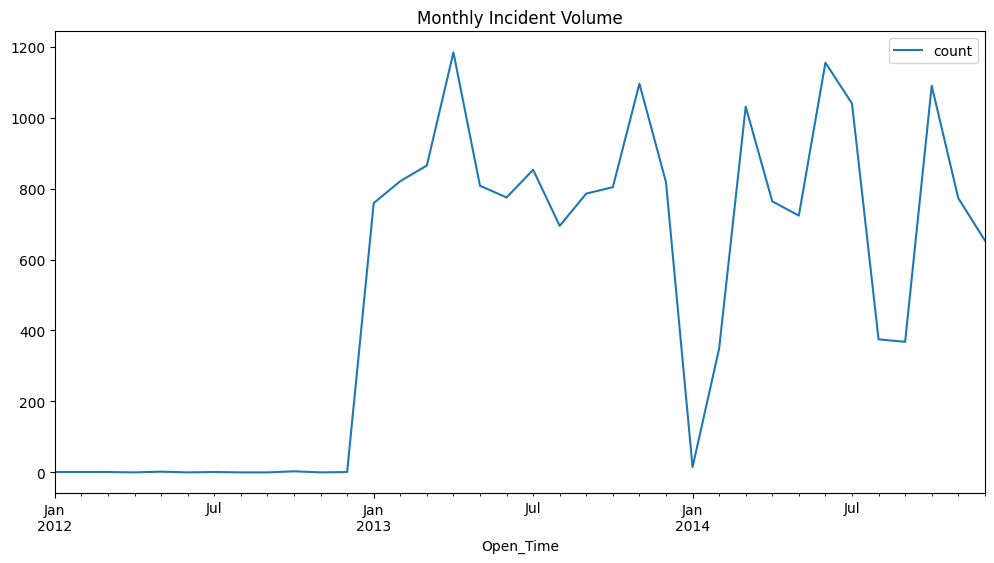

In [22]:
incident_count = df.groupby('Open_Time').size().reset_index(name='count')
incident_count.set_index('Open_Time', inplace=True)

monthly = incident_count.resample('M').sum()

monthly.plot(figsize=(12,6))
plt.title("Monthly Incident Volume")
plt.show()


11:15:37 - cmdstanpy - INFO - Chain [1] start processing
11:15:39 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\ADMIN\Downloads\Project data sets\python\.venv\projects\mini projects\.venv\Lib\site-packages\prophet\forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


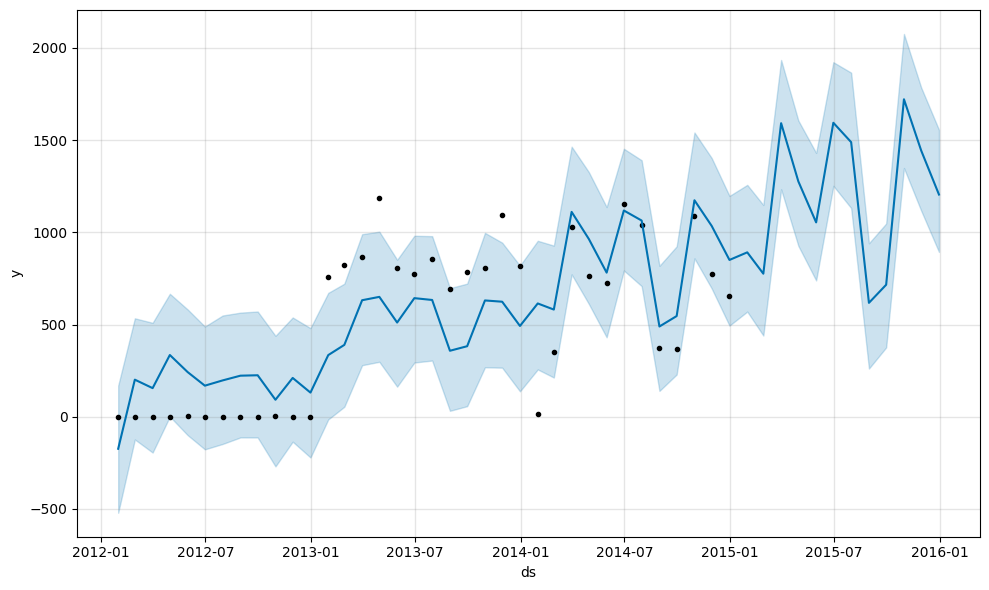

In [23]:
forecast_df = monthly.reset_index()
forecast_df.columns = ['ds','y']

model = Prophet()
model.fit(forecast_df)

future = model.make_future_dataframe(periods=12, freq='M')
forecast = model.predict(future)

model.plot(forecast)
plt.show()


In [24]:
y_multi = df['Priority']

X_train, X_test, y_train, y_test = train_test_split(X,y_multi,test_size=0.2,random_state=42)

multi_model = XGBClassifier()
multi_model.fit(X_train,y_train)

pred_multi = multi_model.predict(X_test)

print(classification_report(y_test,pred_multi))


              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       273
         2.0       0.99      1.00      1.00       143
         3.0       1.00      1.00      1.00      1100
         4.0       1.00      1.00      1.00      4522
         5.0       1.00      1.00      1.00      3284

    accuracy                           1.00      9322
   macro avg       1.00      1.00      1.00      9322
weighted avg       1.00      1.00      1.00      9322



In [25]:
df['Has_Change'] = df['No_of_Related_Changes'].apply(lambda x: 1 if x>0 else 0)

features_rfc = ['Impact','Urgency','No_of_Reassignments','Handle_Time_hrs']

X = df[features_rfc]
y = df['Has_Change']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

rfc_model = RandomForestClassifier()
rfc_model.fit(X_train,y_train)

pred_rfc = rfc_model.predict(X_test)

print(classification_report(y_test,pred_rfc))


              precision    recall  f1-score   support

           0       0.99      1.00      0.99      9222
           1       0.00      0.00      0.00       100

    accuracy                           0.99      9322
   macro avg       0.49      0.50      0.50      9322
weighted avg       0.98      0.99      0.98      9322

